In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

#Simulate 40 assay runs
runs = np.arange (1,41)

#Positive control Ct values (stable with slight noise)
pos_ct = np.random.normal(loc=25, scale=0.4, size=40)

#Introduce mild drift after run 30
pos_ct[30:] += np.linspace(0, 1.2, 10)

#create dataframe 
df = pd.DataFrame({
    "Run": runs,
    "Positive Control_Ct": pos_ct
})

df.head

<bound method NDFrame.head of     Run  Positive Control_Ct
0     1            25.198686
1     2            24.944694
2     3            25.259075
3     4            25.609212
4     5            24.906339
5     6            24.906345
6     7            25.631685
7     8            25.306974
8     9            24.812210
9    10            25.217024
10   11            24.814633
11   12            24.813708
12   13            25.096785
13   14            24.234688
14   15            24.310033
15   16            24.775085
16   17            24.594868
17   18            25.125699
18   19            24.636790
19   20            24.435079
20   21            25.586260
21   22            24.909689
22   23            25.027011
23   24            24.430101
24   25            24.782247
25   26            25.044369
26   27            24.539603
27   28            25.150279
28   29            24.759745
29   30            24.883323
30   31            24.759317
31   32            25.874245
32   33      

# Plot it!
plt.figure()
plt.plot(df["Run"], df["Positive Control_Ct"], marker = "o")
plt.xlabel ("Run Number")
plt.ylabel ("Ct")
plt.title ("Positive Control Ct Trend Accross Runs")
plt.show()


In [9]:
#Statistcal QC Metric
#Calculate Mean & SD of the positive control

mean_ct = df["Positive Control_Ct"].mean()
std_ct = df["Positive Control_Ct"].std()

#Define Control limits (mean +,- 2SD)
upper_limit= mean_ct + 2 * std_ct
lower_limit = mean_ct - 2 * std_ct

print (f"Mean Ct : {mean_ct:.2f}")
print (f"Upper Control Limit (UCL): {upper_limit:.2f}")
print (f"Lower Control Limit (LCL) : {lower_limit:.2f}")

Mean Ct : 25.06
Upper Control Limit (UCL): 25.98
Lower Control Limit (LCL) : 24.15


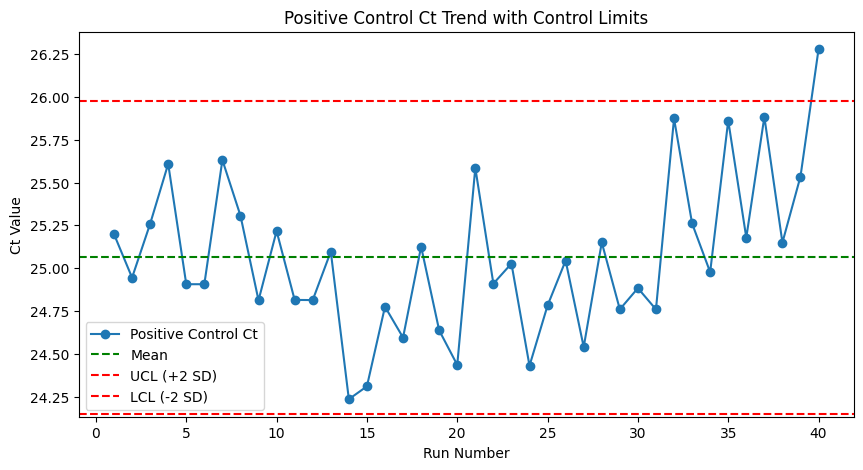

In [11]:
#Plot Control lines
plt.figure(figsize=(10,5))
plt.plot(df["Run"], df["Positive Control_Ct"], marker="o", label="Positive Control Ct")
plt.axhline(mean_ct, color="green", linestyle="--", label="Mean")
plt.axhline(upper_limit, color="red", linestyle="--", label="UCL (+2 SD)")
plt.axhline(lower_limit, color="red", linestyle="--", label="LCL (-2 SD)")
plt.xlabel("Run Number")
plt.ylabel("Ct Value")
plt.title("Positive Control Ct Trend with Control Limits")
plt.legend()
plt.show()

In [13]:
# Adding Pass/Fail logic to evaluate Assay performance 
# Flag runs outside control limits
df["Pass_Fail"] = df["Positive Control_Ct"].apply(
    lambda x: "Fail" if (x > upper_limit) or (x < lower_limit) else "Pass"
)

# Show which runs failed
df[df["Pass_Fail"] == "Fail"]

,Run,Positive Control_Ct,Pass_Fail
39,40,26.278744,Fail


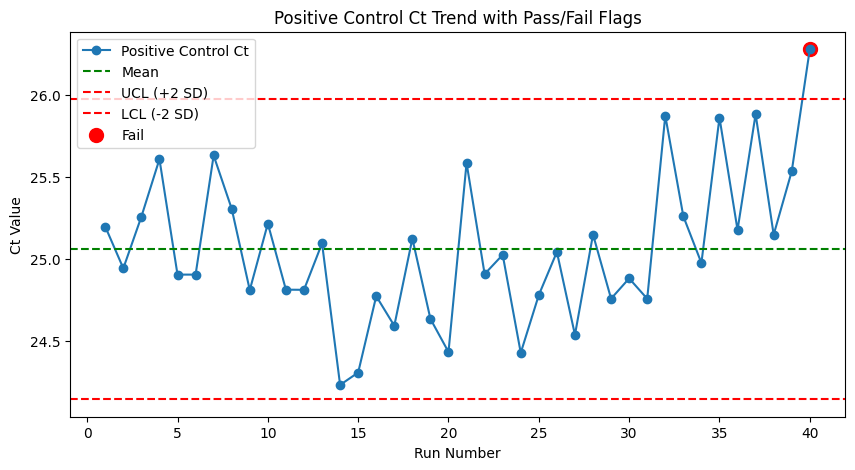

In [14]:
#Highlight Failures on plot
plt.figure(figsize=(10,5))
plt.plot(df["Run"], df["Positive Control_Ct"], marker="o", label="Positive Control Ct")
plt.axhline(mean_ct, color="green", linestyle="--", label="Mean")
plt.axhline(upper_limit, color="red", linestyle="--", label="UCL (+2 SD)")
plt.axhline(lower_limit, color="red", linestyle="--", label="LCL (-2 SD)")

# Highlight failing runs
fail_runs = df[df["Pass_Fail"]=="Fail"]
plt.scatter(fail_runs["Run"], fail_runs["Positive Control_Ct"], color="red", s=100, label="Fail")

plt.xlabel("Run Number")
plt.ylabel("Ct Value")
plt.title("Positive Control Ct Trend with Pass/Fail Flags")
plt.legend()
plt.show()

In [16]:
#simulating Negative controls

# Negative control Ct values (stable, low)
neg_ct = np.random.normal(loc=35, scale=0.3, size=40)

# Add to DataFrame
df["Negative Control_Ct"] = neg_ct

# Negative control mean ± 2 SD
neg_mean = df["Negative Control_Ct"].mean()
neg_upper = neg_mean + 2*df["Negative Control_Ct"].std()
neg_lower = neg_mean - 2*df["Negative Control_Ct"].std()

# Flag failing negative controls
df["Neg_Pass_Fail"] = df["Negative Control_Ct"].apply(
    lambda x: "Fail" if (x > neg_upper) or (x < neg_lower) else "Pass"
)

# Show first few rows
df.head()


,Run,Positive Control_Ct,Pass_Fail,Negative_Control_Ct,Neg_Pass_Fail,Negative Control_Ct
0,1,25.198686,Pass,35.221540,Pass,34.934098
1,2,24.944694,Pass,35.051410,Pass,35.107134
2,3,25.259075,Pass,34.965306,Pass,35.443368
3,4,25.609212,Pass,34.909669,Pass,34.844519
4,5,24.906339,Pass,34.556443,Pass,34.757452


In [17]:
#summarizing overall assay pass/fail rate
# Positive control pass rate
pos_pass_rate = (df["Pass_Fail"] == "Pass").mean() * 100

# Negative control pass rate
neg_pass_rate = (df["Neg_Pass_Fail"] == "Pass").mean() * 100

print(f"Positive Control Pass Rate: {pos_pass_rate:.1f}%")
print(f"Negative Control Pass Rate: {neg_pass_rate:.1f}%")

Positive Control Pass Rate: 97.5%
Negative Control Pass Rate: 92.5%
